### Context engineering in Deep Agents

Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably. Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long-running sessions.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["MISTRAL_API_KEY"]=os.getenv("MISTRAL_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")


#### Context Engineering- Input context- System Prompt

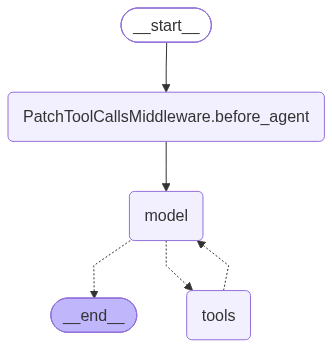

In [3]:
from deepagents import create_deep_agent

agent=create_deep_agent(
    model="groq:openai/gpt-oss-120b",
    system_prompt=(
        "You are a research assistant specializing in scientific literature. "
        "Always cite sources. Use subagents for parallel research on different topics."

    ),
)
agent

In [4]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is deepagent?
================================== Ai Message ==================================
Tool Calls:
  glob (fc_9d4fd3b4-d148-49ac-9873-121acd9fc8c0)
 Call ID: fc_9d4fd3b4-d148-49ac-9873-121acd9fc8c0
  Args:
    path: None
    pattern: *deepagent*
================================= Tool Message =================================
Name: glob

No files found
================================== Ai Message ==================================

**DeepAgent** is a term that can refer to two closely‑related ideas in the field of artificial intelligence:

| Meaning | Description | Typical Use‑Cases | Key References |
|---------|-------------|-------------------|----------------|
| **1. “Deep agent” as a generic AI concept** | A *deep agent* is an autonomous decision‑making system whose perception, reasoning, or policy is powered by deep‑learning models (e.g., convolutional or recurrent neural networks). In r

### Context Engineering with AGENTS.md

Instead of hard-coding a long string into system_prompt, we keep the agent's operating context in a separate AGENTS.md file. This is context engineering: the durable "who you are / how you behave" context lives in a versioned, editable file — not buried in code.

In [24]:
from pathlib import Path
agents_md=Path("projects/AGENTS.md").read_text(encoding="utf-8")
agents_md

'# Agents.md — Deep Agent Context\n\nThis file is meant to be loaded as context whenever a deep agent is invoked\nin this project. It summarizes the architecture, components, and conventions\nused across the notebooks in `deepagent/` so an agent has a consistent mental\nmodel before it starts planning or executing tasks.\n\n## What is a Deep Agent\n\nA "deep agent" (as implemented via LangChain\'s `deepagents` / `langgraph`\nbuilding blocks) is an agent architecture designed for long-horizon,\nmulti-step tasks — as opposed to a single-shot ReAct loop. It combines four\ncore pieces:\n\n1. **Planning tool** — an explicit todo/plan tool the agent uses to break a\n   task into steps, track progress, and revise the plan as it learns more.\n   This keeps the agent goal-directed over many tool calls instead of\n   drifting.\n2. **Sub-agents** — the main agent can delegate a bounded piece of work to a\n   sub-agent with its own context window. This isolates noisy tool output\n   (search result

In [25]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer=MemorySaver()

# Backends: where the agent's files / memory live

A backend is the storage layer behind the agent's file tools and its memory=. Same agent code, different durability:
| Backend | Lives in | Survives across | Use it when… |
| --- | --- | --- | --- |
| **StateBackend** (default) | LangGraph state (the `files` channel) | One thread (with a checkpointer) | Scratch/working files for a single run or conversation. Ephemeral by design. |
| **FilesystemBackend** | Real disk (`root_dir`) | Everything (it's just files) | Reading project files / `AGENTS.md` that already exist on disk. |
| **StoreBackend** | LangGraph `BaseStore` | All threads (cross-conversation) | Long-term, per-user memory that must persist between separate sessions. |

In [26]:
agent = create_deep_agent(
    model="mistral-small-latest",
    checkpointer=MemorySaver(),
    # no backend, no memory=, no files=
)
result = agent.invoke(
    {
       "messages": [
            {"role": "user", "content": f"Here is our project guide:\n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I’m a **deep agent** invoked within this project, and I should follow the guidance in **Agents.md** as my primary context. Here’s how I’ll operate based on that guide:

---

### **My Role and Constraints**
1. **Goal-Directed Planning**
   - I will **always** start by creating or consulting a plan (using the planning tool) to break tasks into steps, track progress, and adapt as I learn. This prevents me from drifting or losing focus over multiple tool calls.

2. **Sub-Agent Delegation**
   - If a task involves exploratory work (e.g., searching files, reading multiple notebooks, or researching patterns), I’ll delegate it to a **sub-agent** to isolate noise and keep my context clean. Only the sub-agent’s final report will re-enter my context.

3. **Filesystem as External Memory**
   - I’ll write intermediate artifacts (e.g., drafts, notes, extracted data) to files under `deepagent/projects/` or a scratch subfolder, rather than bloating my context window. Tools like `ls`, `read_file`, `wri

In [27]:
agent = create_deep_agent(
    model="mistral-small-latest",
    memory=["projects/AGENTS.md"],
    checkpointer = MemorySaver()
)

In [28]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

{'content': '# Agents.md — Deep Agent Context\n\nThis file is meant to be loaded as context whenever a deep agent is invoked\nin this project. It summarizes the architecture, components, and conventions\nused across the notebooks in `deepagent/` so an agent has a consistent mental\nmodel before it starts planning or executing tasks.\n\n## What is a Deep Agent\n\nA "deep agent" (as implemented via LangChain\'s `deepagents` / `langgraph`\nbuilding blocks) is an agent architecture designed for long-horizon,\nmulti-step tasks — as opposed to a single-shot ReAct loop. It combines four\ncore pieces:\n\n1. **Planning tool** — an explicit todo/plan tool the agent uses to break a\n   task into steps, track progress, and revise the plan as it learns more.\n   This keeps the agent goal-directed over many tool calls instead of\n   drifting.\n2. **Sub-agents** — the main agent can delegate a bounded piece of work to a\n   sub-agent with its own context window. This isolates noisy tool output\n   (s

In [29]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md)},  # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I don’t have persistent memory between conversations unless you explicitly ask me to remember something or I save information during our interaction. Right now, my memory is empty, and I don’t have any stored information about you or previous interactions.

As for who I am: I’m an AI assistant designed to help you with tasks like:
- Answering questions and providing explanations.
- Reading, editing, or analyzing files on your system.
- Writing code, debugging, or generating examples.
- Searching for files or content.
- Performing multi-step tasks using tools.

If you’d like, I can remember specific details about you or our interactions—just let me know! For example:
- Your preferences (e.g., coding language, tool usage).
- Important information (e.g., file paths, usernames, settings).
- Feedback from our conversations to improve future interactions.


In [33]:
# --- StoreBackend: persistent, cross-thread memory ---
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.
from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file.
store.put(("memories",), "AGENTS.md", create_file_data(agents_md))

store_agent = create_deep_agent(
    model="mistral-small-latest",
    backend=StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],            
    store=store,
    checkpointer=MemorySaver(),
)

# Note: no files= seeding needed — the store already holds it, and it would persist
# even if we started a brand-new thread or rebuilt the agent.
result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "store-demo-1"}},
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What's in your memory? Who are you?
================================== Ai Message ==================================

I don’t have persistent memory between conversations unless we explicitly save information during our interaction. Currently, no memory is loaded from previous sessions.

As for who I am:
- I’m an AI assistant designed to help you with tasks like reading, writing, editing files, searching for information, and performing multi-step operations.
- I don’t have a persistent identity or goals outside of our current conversation, but I can adapt to your preferences and remember details *within* this conversation if you ask me to save them.

If you’d like, I can save specific details about you or our preferences to memory for future use. Just let me know!


In [35]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.
fs_agent = create_deep_agent(
    model="mistral-small-latest",
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],                           
    checkpointer=MemorySaver(),
)

result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What's in your memory? Who are you?
================================== Ai Message ==================================

I’m a deep agent in this environment, and my persistent memory is loaded from the **AGENTS.md** file in the `deepagent/` directory (you can see its full contents in the `<agent_memory>` block above). That file summarizes:

- **What a deep agent is** (planning tool, sub-agents, virtual filesystem, detailed system prompt).
- **Backends** (in-memory, filesystem, store-backed).
- **Context engineering** techniques to avoid context overflow.
- **Conventions** for this project (notebook order, API keys, LangChain v1.x).
- **Guidelines** for when I’m invoked as a deep agent: prefer files over context, use planning, delegate to sub-agents, and update my memories promptly when the user provides useful information.

I don’t have any other persistent memories beyond what’s in that file and what you t

In [36]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What's in your memory? Who are you?
================================== Ai Message ==================================

I’m a deep agent in this environment, and my persistent memory is loaded from the **AGENTS.md** file in the `deepagent/` directory (you can see its full contents in the `<agent_memory>` block above). That file summarizes:

- **What a deep agent is** (planning tool, sub-agents, virtual filesystem, detailed system prompt).
- **Backends** (in-memory, filesystem, store-backed).
- **Context engineering** techniques to avoid context overflow.
- **Conventions** for this project (notebook order, API keys, LangChain v1.x).
- **Guidelines** for when I’m invoked as a deep agent: prefer files over context, use planning, delegate to sub-agents, and update my memories promptly when the user provides useful information.

I don’t have any other persistent memories beyond what’s in that file and what you t

### Skills - Memory Context

In [9]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

from pathlib import Path
skills_content= Path("skills/langgraph/SKILL.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/langgraph/SKILL.md": create_file_data(skills_content),
}

In [10]:
## To read every skills

skill_dirs = ["langgraph", "python", "aws", "report-writer"]
skills_files = {
    f"/skills/{name}/SKILL.md": create_file_data(
        Path(f"skills/{name}/SKILL.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}

In [11]:
skills_files

{'/skills/langgraph/SKILL.md': {'content': "---\nname: langgraph\ndescription: Design and implement LangGraph graphs, nodes, edges, state schemas, checkpointers, and deep-agent architectures (planning tool, sub-agents, virtual filesystem) used in this repo's deepagent notebooks. Use when the user asks about building agents, graphs, state machines, tool-calling loops, or deep agents with LangChain v1 / LangGraph / deepagents.\nmetadata:\n  type: framework\n  framework: langgraph\n---\n\n# LangGraph Skill\n\n## When to Use\n- The user asks to build, modify, or debug a LangGraph graph (nodes, edges, conditional routing, state schema).\n- The user asks about deep agents (`deepagents` package): planning tool, sub-agents, virtual filesystem, backends.\n- The user asks about persistence/checkpointing, streaming, or human-in-the-loop patterns in LangGraph.\n- The task touches notebooks under `deepagent/` (`1-basicdeepagent.ipynb`, `2-contextengineering.ipynb`, `3-backends.ipynb`).\n\n## How to

In [ ]:
agent=create_deep_agent(
    model="groq:openai/gpt-oss-120b",
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use each?"}],
        
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo1"}},
)

print(result["messages"][-1].content)

**Available Skills**

| Skill | What it Covers | Typical Use‑Cases |
|-------|----------------|-------------------|
| **aws** | Working with Amazon Web Services (S3, IAM, Lambda, ECS/EC2, Bedrock, boto3, etc.) – writing SDK code, designing policies, provisioning resources, and integrating AWS services into Python/LLM projects. | • Generate or modify boto3 scripts.<br>• Draft least‑privilege IAM policies.<br>• Explain how to wire an S3 bucket to a Lambda function.<br>• Show the correct way to store credentials or use IAM roles.<br>• Provide architecture diagrams that involve AWS services. |
| **langgraph** | Designing and implementing LangGraph graphs, nodes, edges, state schemas, checkpointers, and deep‑agent architectures (planning tools, sub‑agents, virtual file‑system) used in this repo’s DeepAgent notebooks. | • Build a LangGraph workflow (e.g., a planning‑loop or tool‑calling graph).<br>• Define state models with pydantic/TypedDict.<br>• Add checkpoints, persistence, or sub‑agents

In [ ]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.",       
          }],
          "files": skills_files,   
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.
================================== Ai Message ==================================
Tool Calls:
  ls (fc_e7b58e7c-a767-4dd3-939d-5aaa238600ce)
 Call ID: fc_e7b58e7c-a767-4dd3-939d-5aaa238600ce
  Args:
    path: /skills/langgraph
================================= Tool Message =================================
Name: ls

['/skills/langgraph/SKILL.md']
================================== Ai Message ==================================
Tool Calls:
  read_file (fc_eb6617cd-8ca1-4c59-b1a6-34e30c33e7e2)
 Call ID: fc_eb6617cd-8ca1-4c59-b1a6-34e30c33e7e2
  Args:
    file_path: /skills/langgraph/SKILL.md
    limit: 2000
================================= Tool Message =================================
Name: read_file

 1  ---
 2  name: langgraph
 3  description: Design and implement LangGraph graphs, nodes, edges, state schemas, ch

In [15]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do i set up an EC2  insstance in AWS.",       
          }],
          "files": skills_files,   
      },
      config={"configurable": {"thread_id": "skills-demo-3"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do i set up an EC2  insstance in AWS.
================================== Ai Message ==================================
Tool Calls:
  read_file (fc_72fea526-9a73-4402-ad59-23e974802a68)
 Call ID: fc_72fea526-9a73-4402-ad59-23e974802a68
  Args:
    file_path: /skills/aws/SKILL.md
    limit: 1000
================================= Tool Message =================================
Name: read_file

 1  ---
 2  name: aws
 3  description: Guidance for working with AWS services (S3, IAM, Lambda, ECS/EC2, Bedrock, boto3) safely — including credential handling, least-privilege IAM, and typical integration patterns for LLM apps. Use when the user asks to write AWS SDK (boto3) code, design IAM policies, provision or reference AWS infrastructure, or integrate a service (S3, Bedrock, Lambda, etc.) into this project.
 4  metadata:
 5    type: cloud
 6    provider: aws
 7  ---
 8  
 9  # AWS Skill
10  
11  ## When to Use

In [16]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "write me a python code to do binary search",       
          }],
          "files": skills_files,  
      },
      config={"configurable": {"thread_id": "skills-demo-4"}},
  )

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

write me a python code to do binary search
================================== Ai Message ==================================
Tool Calls:
  read_file (fc_436b1dbb-4d3d-4707-a64f-b16efe218daa)
 Call ID: fc_436b1dbb-4d3d-4707-a64f-b16efe218daa
  Args:
    file_path: /skills/python/SKILL.md
    limit: 1000
================================= Tool Message =================================
Name: read_file

 1  ---
 2  name: python
 3  description: Write, review, and debug Python code following idiomatic style, typing, and packaging conventions used in this repo (uv, pyproject.toml, Python 3.14+). Use when the user asks to write/modify Python scripts, fix a Python bug, design a module/class, add type hints, or set up dependencies with uv.
 4  metadata:
 5    type: language
 6    language: python
 7  ---
 8  
 9  # Python Skill
10  
11  ## When to Use
12  - The user asks to write, review, refactor, or debug Python c